In [28]:
from src.data_utils import load_tg_csv, TRAIN_DATA_PATH, TEST_DATA_PATH, VALIDATION_DATA_PATH

X_train_data, Y_train_data = load_tg_csv(TRAIN_DATA_PATH)
X_test_data, Y_test_data = load_tg_csv(TEST_DATA_PATH)
X_validation_data, Y_validation_data = load_tg_csv(VALIDATION_DATA_PATH)
print(TRAIN_DATA_PATH, TEST_DATA_PATH, VALIDATION_DATA_PATH)

C:\Users\simon\Desktop\Regroupement\Back_up_stuff\All_stuff\AI4Chem\data\PolyMetriX\processed\tg_train.csv C:\Users\simon\Desktop\Regroupement\Back_up_stuff\All_stuff\AI4Chem\data\PolyMetriX\processed\tg_test.csv C:\Users\simon\Desktop\Regroupement\Back_up_stuff\All_stuff\AI4Chem\data\PolyMetriX\processed\tg_validation.csv


In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

In [43]:
def mol_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)

    # ── Features atomiques (node features) ────────────────────────────────
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),           # type d'atome : C=6, O=8, N=7…
            atom.GetDegree(),              # nombre de liaisons
            atom.GetFormalCharge(),        # charge formelle
            int(atom.GetIsAromatic()),     # aromatique ? 0 ou 1
            atom.GetTotalNumHs(),          # hydrogènes implicites
        ])
    x = torch.tensor(atom_features, dtype=torch.float)

    # ── Features de liaisons (edge features) ──────────────────────────────
    # C'est ce que GCNConv ignorait et que GATConv exploite
    edge_index = []
    edge_attr  = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        bond_type = bond.GetBondTypeAsDouble()
        # 1.0 = simple, 1.5 = aromatique, 2.0 = double, 3.0 = triple

        edge_index += [[i, j], [j, i]]    # les deux sens
        edge_attr  += [[bond_type], [bond_type]]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


In [53]:
class MolecularGAT(nn.Module):
    def __init__(self, node_features=5, edge_features=1,
                 hidden=64, heads=4, output=1, dropout=0.2):
        super().__init__()

        self.conv1 = GATConv(node_features, hidden, heads=heads,
                             edge_dim=edge_features, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden*heads, hidden, heads=heads,
                             edge_dim=edge_features, dropout=dropout, concat=True)
        self.conv3 = GATConv(hidden*heads, hidden, heads=heads,
                             edge_dim=edge_features, dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden * heads)
        self.bn2 = nn.BatchNorm1d(hidden * heads)
        self.bn3 = nn.BatchNorm1d(hidden)

        self.skip2to3 = nn.Linear(hidden * heads, hidden, bias=False)

        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 32),  # hidden*2 car on cat h_mean + h_max
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, output)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, edge_attr, batch):
        # ── Couche 1 ───────────────────────────────────────────────────────
        h1 = self.conv1(x,  edge_index, edge_attr=edge_attr)
        h1 = self.bn1(h1)
        h1 = torch.relu(h1)
        h1 = self.dropout(h1)
        # forme : (n_atoms, hidden*heads)

        # ── Couche 2 + skip connection ─────────────────────────────────────
        h2 = self.conv2(h1, edge_index, edge_attr=edge_attr)
        h2 = self.bn2(h2)
        h2 = torch.relu(h2)
        h2 = self.dropout(h2)
        h2 = h2 + h1
        # forme : (n_atoms, hidden*heads)

        # ── Couche 3 + skip connection projetée ────────────────────────────
        h3 = self.conv3(h2, edge_index, edge_attr=edge_attr)
        h3 = self.bn3(h3)
        h3 = torch.relu(h3)
        h3 = h3 + self.skip2to3(h2)
        # forme : (n_atoms, hidden)

        # ── Readout : atomes → molécule ────────────────────────────────────
        h_mean = global_mean_pool(h3, batch)         # (batch, hidden)
        h_max  = global_max_pool(h3, batch)          # (batch, hidden)
        h      = torch.cat([h_mean, h_max], dim=1)  # (batch, hidden*2)

        # ── Prédiction ─────────────────────────────────────────────────────
        return self.head(h).squeeze()   # (batch,)


In [68]:
scaler = StandardScaler()
Y_train_norm = scaler.fit_transform(
    np.array(Y_train_data).reshape(-1, 1)
).flatten()
Y_val_norm = scaler.transform(                    # transform seulement, pas fit !
    np.array(Y_validation_data).reshape(-1, 1)
).flatten()

# ── 2. Construire les graphes ─────────────────────────────────────────────
torch.manual_seed(1)

train_graphs = [mol_to_graph(smi) for smi in X_train_data]
for g, tg in zip(train_graphs, Y_train_norm):     # ← Tg normalisées
    g.y = torch.tensor([tg], dtype=torch.float)

val_graphs = [mol_to_graph(smi) for smi in X_validation_data]
for g, tg in zip(val_graphs, Y_val_norm):         # ← Tg normalisées
    g.y = torch.tensor([tg], dtype=torch.float)

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_graphs,   batch_size=32, shuffle=False)  # ← False

# ── 3. Modèle réduit ─────────────────────────────────────────────────────
model = MolecularGAT(node_features=5, edge_features=1,
                     hidden=32,
                     heads=2,
                     dropout=0.3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=15, factor=0.5
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, epochs_no_improve = 10, 0     # patience augmentée

# ── 4. Boucle d'entraînement ─────────────────────────────────────────────
for epoch in range(30):                 # ← 10 → 300

    model.train()
    batch_losses = []
    for batch in train_loader:
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(pred, batch.y.squeeze())
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(sum(batch_losses) / len(batch_losses))

    model.eval()
    batch_losses_val = []
    with torch.no_grad():
        for batch in val_loader:
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            loss = criterion(pred, batch.y.squeeze())
            batch_losses_val.append(loss.item())
    val_loss = sum(batch_losses_val) / len(batch_losses_val)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_gat.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping à l'époque {epoch}")
            break

    if epoch % 5 == 0:
        # Convertir la val loss normalisée en RMSE en Kelvin
        rmse_K = np.sqrt(val_loss) * scaler.scale_[0]
        print(f"Epoch {epoch:3d} | Train {train_losses[-1]:.4f} "
              f"| Val {val_loss:.4f} | RMSE {rmse_K:.1f} K")

# ── 5. Évaluation finale en Kelvin ───────────────────────────────────────
model.load_state_dict(torch.load('best_gat.pt'))
print(f"\nMeilleur RMSE : {np.sqrt(best_val_loss) * scaler.scale_[0]:.1f} K")

Epoch   0 | Train 0.5668 | Val 0.3732 | RMSE 69.0 K
Epoch   5 | Train 0.3711 | Val 0.3084 | RMSE 62.7 K
Epoch  10 | Train 0.3245 | Val 0.3019 | RMSE 62.1 K
Epoch  15 | Train 0.3187 | Val 0.2532 | RMSE 56.8 K
Epoch  20 | Train 0.3085 | Val 0.3523 | RMSE 67.0 K
Epoch  25 | Train 0.3027 | Val 0.2288 | RMSE 54.0 K

Meilleur RMSE : 54.0 K


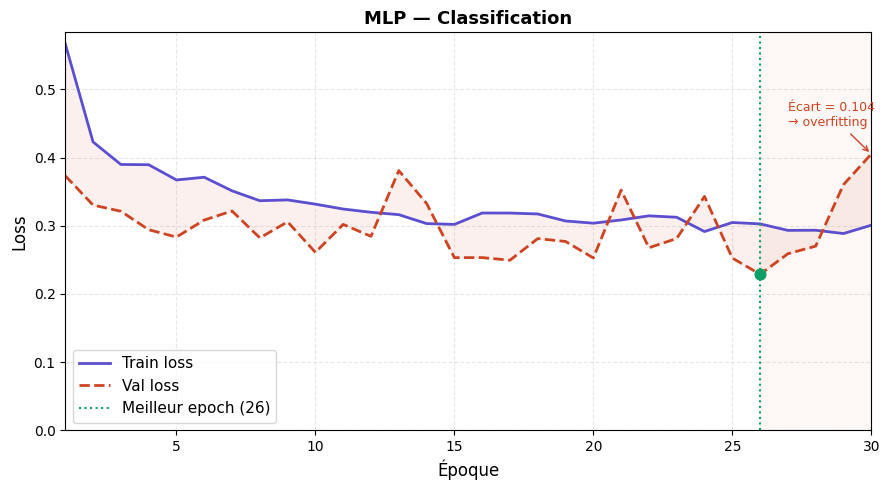

Meilleur epoch : 26, Val loss = 0.2288


In [69]:


def plot_training_curves(train_losses, val_losses, title="Courbes d'entraînement"):

    epochs = range(1, len(train_losses) + 1)

    fig, ax = plt.subplots(figsize=(9, 5))

    # ── Courbes principales ────────────────────────────────────────────────
    ax.plot(epochs, train_losses, color='#5b4fcf', linewidth=2,
            label='Train loss')
    ax.plot(epochs, val_losses,   color='#cc4422', linewidth=2,
            linestyle='--', label='Val loss')

    # ── Zone entre les deux courbes (écart overfitting) ───────────────────
    ax.fill_between(epochs, train_losses, val_losses,
                    alpha=0.08, color='#cc4422')

    # ── Early stopping : marquer le meilleur epoch ────────────────────────
    best_epoch = int(np.argmin(val_losses)) + 1
    best_val   = min(val_losses)

    ax.axvline(x=best_epoch, color='#0f9e65', linewidth=1.5,
               linestyle=':', label=f'Meilleur epoch ({best_epoch})')
    ax.scatter([best_epoch], [best_val], color='#0f9e65', zorder=5, s=60)

    # ── Annotation de l'overfitting si présent ────────────────────────────
    last_gap = val_losses[-1] - train_losses[-1]
    if last_gap > 0.05:
        ax.annotate(f'Écart = {last_gap:.3f}\n→ overfitting',
                    xy=(len(epochs), val_losses[-1]),
                    xytext=(-60, 20), textcoords='offset points',
                    fontsize=9, color='#cc4422',
                    arrowprops=dict(arrowstyle='->', color='#cc4422'))

    # ── Mise en forme ──────────────────────────────────────────────────────
    ax.set_xlabel('Époque', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(1, len(epochs))
    ax.set_ylim(bottom=0)

    # Fond légèrement coloré pour la zone "après best epoch"
    ax.axvspan(best_epoch, len(epochs), alpha=0.04, color='#cc4422')

    plt.tight_layout()
    plt.show()

# Appel
plot_training_curves(train_losses, val_losses, title="MLP — Classification")
print(f"Meilleur epoch : {np.argmin(val_losses) + 1}, Val loss = {min(val_losses):.4f}")

RMSE: 55.48


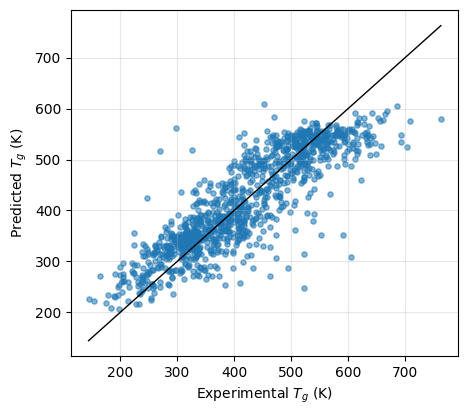

In [70]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))
model = MolecularGAT(node_features=5, edge_features=1, hidden=32, heads=2)
model.load_state_dict(torch.load('best_gat.pt'))
model.eval()   

# Convertir en graphes — même fonction que pendant l'entraînement
# Pas besoin de .y ici puisqu'on n'a pas les labels
new_graphs = [mol_to_graph(smi) for smi in X_test_data]

# DataLoader pour batcher proprement
infer_loader = DataLoader(new_graphs, batch_size=64, shuffle=False)
#                                                     ↑
#                                     shuffle=False obligatoire
#                                     pour garder l'ordre des molécules

# ── 3. Inférence ──────────────────────────────────────────────────────────
predictions = []

with torch.no_grad():                # pas de gradient — plus rapide, moins de mémoire
    for batch in infer_loader:
        pred = model(batch.x,
                     batch.edge_index,
                     batch.edge_attr,
                     batch.batch)
        predictions.extend(pred.tolist())   # tenseur → liste Python

predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
y_true = Y_test_data
y_pred = predictions





plt.figure(figsize=(5, 4.5))
plt.scatter(y_true, y_pred, s=14, alpha=0.55, color="tab:blue")
low = min(y_true.min(), y_pred.min())
high = max(y_true.max(), y_pred.max())
plt.plot([low, high], [low, high], color="black", linewidth=1)
plt.xlabel("Experimental $T_g$ (K)")
plt.ylabel("Predicted $T_g$ (K)")
plt.grid(alpha=0.3)
print(f"RMSE: {rmse(y_true, y_pred):.2f}")